# **Modelo de Random Forest**

### **Cargar datos**

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score

df = pd.read_csv('../data/datos_limpios_multivariado.csv')

### **Modelo**

In [9]:
features = [
    'financial_label', 'ch_age',
    'ch_school_type_label', 'education_label',
    'employment_label'
]
target = 'ch_situation_label'

df_rf = df[features + [target]].dropna()
X = df_rf[features].copy()
encoder = OrdinalEncoder()
X[features] = encoder.fit_transform(X[features])
y = df_rf[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Entrenamiento y predicción
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=10, class_weight='balanced'
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Reporte de clasificación
print("Reporte de clasificación (Random Forest):")
print(classification_report(y_test, y_pred))

Reporte de clasificación (Random Forest):
               precision    recall  f1-score   support

       hybrid       0.15      0.29      0.20      1335
    in_person       0.61      0.52      0.56      5761
not_in_school       0.12      0.30      0.17       832
       remote       0.53      0.35      0.42      4852

     accuracy                           0.42     12780
    macro avg       0.35      0.36      0.34     12780
 weighted avg       0.50      0.42      0.44     12780



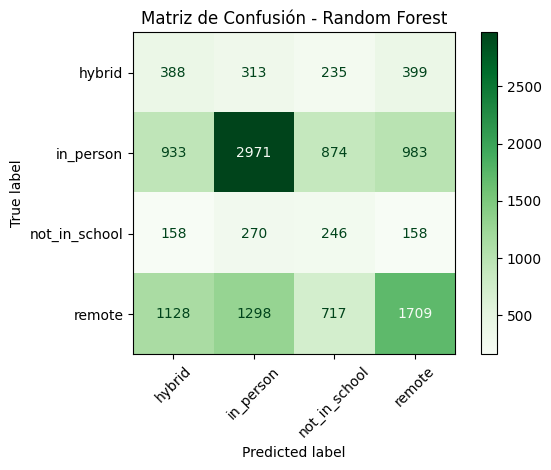

In [11]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(xticks_rotation=45, cmap='Greens')
plt.title("Matriz de Confusión - Random Forest")
plt.tight_layout()
plt.show()

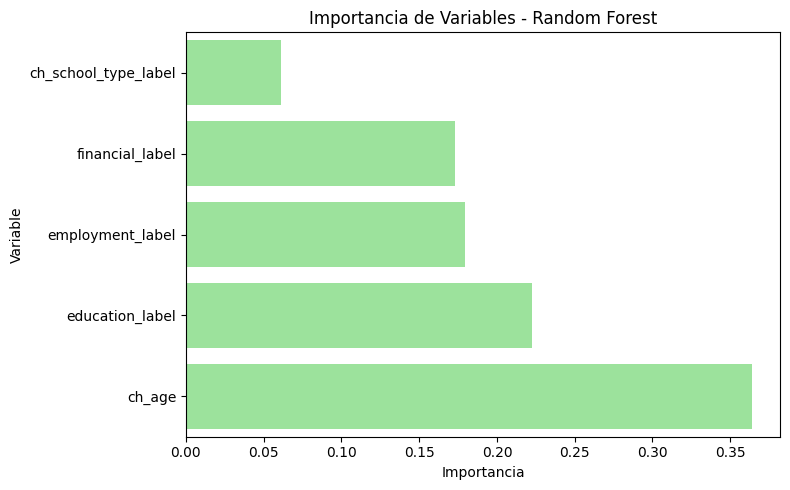

In [13]:
# Importancia de las variables
importancias_rf = pd.Series(rf_model.feature_importances_, index=features)
importancias_rf = importancias_rf.sort_values(ascending=True)

plt.figure(figsize=(8,5))
sns.barplot(x=importancias_rf, y=importancias_rf.index, color='lightgreen')
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


## Modelo de Clasificación: Random Forest

Como segundo modelo, se entrenó un Random Forest con las 5 variables más importantes previamente identificadas:

- `financial_label`
- `ch_age`
- `ch_school_type_label`
- `education_label`
- `employment_label`

### Configuración del modelo

- `n_estimators = 100`
- `max_depth = 10`
- `class_weight = 'balanced'`
- División del dataset: 70% entrenamiento / 30% prueba

### Resultados del modelo

| Métrica         | Árbol Decisión | Random Forest |
|------------------|----------------|----------------|
| Accuracy         | 0.53           | 0.42           |
| Macro F1-score   | 0.29           | 0.34           |
| Weighted F1-score| 0.48           | 0.44           |

El accuracy baja, pero el F1 macro sube ligeramente.  
Esto indica que Random Forest mejora la equidad entre clases, especialmente en clases como `hybrid` y `not_in_school`.

### Matriz de Confusión

- A diferencia del Árbol, Random Forest logra capturar parcialmente a todas las clases, aunque sigue confundiendo con frecuencia `remote` e `in_person`.
- Mejora especialmente en clases previamente ignoradas (`hybrid`, `not_in_school`).

### Importancia de Variables

La variable `ch_age` domina la predicción.  
También se observa un mayor uso de `education` y `employment`, a diferencia del árbol anterior donde `financial_label` era más dominante.

### Observaciones finales

- Generaliza mejor entre clases que el árbol de decisión.
- Tiene una mejor distribución de recall, especialmente en clases vulnerables.
- Sin embargo, no supera al árbol en precisión general.

In [15]:
# Parámetros para búsqueda aleatoria
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Métrica personalizada
f1_macro_scorer = make_scorer(f1_score, average='macro')

# Modelo base
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Randomized Search
rs = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring=f1_macro_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Entrenamiento
rs.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(rs.best_params_)

best_rf = rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\andy-\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Mejores parámetros encontrados:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}


In [16]:
# Predicción
y_pred_best = best_rf.predict(X_test)

# Reporte de clasificación
print("Reporte de clasificación - Modelo Optimizado:")
print(classification_report(y_test, y_pred_best))

Reporte de clasificación - Modelo Optimizado:
               precision    recall  f1-score   support

       hybrid       0.14      0.31      0.19      1335
    in_person       0.62      0.44      0.51      5761
not_in_school       0.11      0.33      0.17       832
       remote       0.49      0.33      0.39      4852

     accuracy                           0.38     12780
    macro avg       0.34      0.35      0.32     12780
 weighted avg       0.49      0.38      0.41     12780



## Modelo Random Forest (Optimizado con RandomizedSearchCV)

Se utilizó `RandomizedSearchCV` para ajustar hiperparámetros del modelo con base en la métrica `f1_macro`, explorando combinaciones de profundidad, número de árboles, número mínimo de muestras por hoja, etc.

### Hiperparámetros óptimos encontrados:

```python
{
  'n_estimators': 200,
  'min_samples_split': 2,
  'min_samples_leaf': 4,
  'max_features': 'log2',
  'max_depth': None,
  'bootstrap': False
}
```

### Resultados del modelo

| Métrica | Modelo anterior | Modelo optimizado|
|---------|-----------------|------------------|
| Accuracy | 0.42 | 0.38 |
| F1 Macro | 0.34 | 0.32 |
| F1 weighted | 0.44 | 0.41 |

Aunque el modelo optimizado explora mayor profundidad (max_depth=None), no logra mejorar significativamente las métricas generales. Incluso desciende ligeramente en precisión general y F1-score, posiblemente por overfitting o falta de generalización.

### Matriz de confusión

Se observó una mejora marginal en la predicción de clases minoritarias (hybrid, not_in_school), pero con sacrificio de precisión en in_person y remote. La matriz muestra que los errores siguen distribuyéndose entre clases frecuentes. La variable ch_age sigue siendo la más influyente.

### Observaciones finales

El uso de RandomizedSearchCV permitió encontrar una combinación funcional de hiperparámetros, pero no mejoró los resultados globales. El modelo original (con parámetros por defecto y 5 variables seleccionadas) mostró mejor equilibrio entre precisión y cobertura.

### **Modelo con las variables del cuidador**

In [18]:
features = [
    'gender', 'age',
    'financial_label',
    'education_label'
]

target = 'ch_situation_label'

df_rf = df[features + [target]].dropna()
X = df_rf[features].copy()
encoder = OrdinalEncoder()
X[features] = encoder.fit_transform(X[features])
y = df_rf[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Entrenamiento y predicción
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=10, class_weight='balanced'
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Reporte de clasificación
print("Reporte de clasificación (Random Forest):")
print(classification_report(y_test, y_pred))

Reporte de clasificación (Random Forest):
               precision    recall  f1-score   support

       hybrid       0.17      0.20      0.18      1335
    in_person       0.59      0.54      0.56      5761
not_in_school       0.09      0.31      0.14       832
       remote       0.53      0.34      0.42      4852

     accuracy                           0.41     12780
    macro avg       0.35      0.35      0.33     12780
 weighted avg       0.49      0.41      0.44     12780



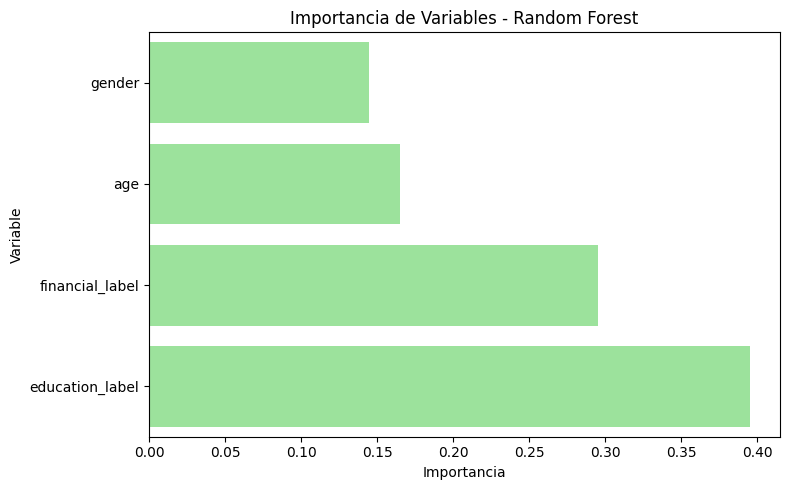

In [19]:
# Importancia de las variables
importancias_rf = pd.Series(rf_model.feature_importances_, index=features)
importancias_rf = importancias_rf.sort_values(ascending=True)

plt.figure(figsize=(8,5))
sns.barplot(x=importancias_rf, y=importancias_rf.index, color='lightgreen')
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## Comparación entre Modelo Completo vs. Modelo con 4 Variables

Se comparan dos versiones del modelo de Random Forest para predecir la situación educativa de los niños:

### Modelos evaluados

- **Modelo Completo**: Usó todas las variables seleccionadas del niño y del cuidador.
- **Modelo con 4 Variables**: Solo incluyó:
  - `gender`
  - `age`
  - `financial_label`
  - `education_label`

### Resultados comparativos

| Métrica            | RF Completo            | RF 4 Variables           |
|--------------------|------------------------|--------------------------|
| **Accuracy**       | 0.42                   | 0.41                     |
| **F1 Macro**       | 0.34                   | 0.33                     |
| **F1 Weighted**    | 0.44                   | 0.44                     |

#### F1-Score por clase

| Clase             | RF Completo | RF 4 vars |
|------------------|-------------|-----------|
| `hybrid`         | 0.20        | 0.18      |
| `in_person`      | 0.56        | 0.56      |
| `not_in_school`  | 0.17        | 0.14      |
| `remote`         | 0.42        | 0.42      |

### Análisis

- A pesar de reducir el número de variables, el rendimiento se mantuvo estable.
- Las clases mayoritarias (`in_person`, `remote`) fueron predichas con la misma efectividad.
- Las clases menos representadas (`hybrid`, `not_in_school`) siguen siendo un reto común, esperado sin balanceo de clases.

### Conclusión

El modelo reducido con 4 variables mantiene el mismo F1 ponderado que el modelo completo, con menor complejidad.